# Predicción de Precios de Alquiler en Madrid
Proyecto Data Science - Idealista Dataset 

Detallar mejor el proyecto

### Instalación de librerías

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from category_encoders import TargetEncoder



### Estudio de los datos del dataset

In [20]:
df = pd.read_csv('./data/Datos.csv')

print('Tamaño original del dataset:', df.shape)


Tamaño original del dataset: (11826, 14)


In [21]:
print('\nPrimeras filas:')
df.head()


Primeras filas:


,provincia,zona,titulo,PrecioActual,PrecioAnterior,metros,habitaciones,ascensor,localizacion,planta,baños,tags,descripcion,Enlace
0,madrid,ciudad-lineal,"Piso en calle de San Marcelo, 22, Ventas, Madrid",355000,0,69,2.0,S,EXTERIOR,5ª,1,"VIVIENDA,LUMINOSO,VISTAS,REFORMADA,PORTERO,EXT...",Particular Vende vivienda totalmente reformada...,https://www.idealista.com/inmueble/106956987/
1,madrid,carabanchel,"Piso en calle Cabo Nicolás Mur, San Isidro, Ma...",149000,159000,91,3.0,N,EXTERIOR,1ª,0,"PISO,EXCLUSIVA,INMOBILIARIA,OPORTUNIDAD",Inmobiliarias Encuentro vende en exclusiva la ...,https://www.idealista.com/inmueble/106906044/
2,madrid,centro,"Piso en calle de Rodas, Lavapiés-Embajadores, ...",195000,0,36,1.0,S,NaN,2ª,0,"EXCLUSIVA,ESTUDIO",ESTUDIO EN PLENO CENTRO DE MADRIDSarago Servic...,https://www.idealista.com/inmueble/107306175/
3,madrid,usera,"Piso en calle de Ferroviarios, Almendrales, Ma...",195000,0,58,1.0,S,INTERIOR,BAJO,0,"VIVIENDA,HOGAR,FUNCIONAL","Esta acogedora vivienda, ubicada en una planta...",https://www.idealista.com/inmueble/106325171/
4,madrid,tetuan,"Dúplex en Bellas Vistas, Madrid",715000,750000,140,3.0,S,EXTERIOR,2ª,0,"TERRAZA,EXCLUSIVA,MODERNO","Maravilloso ATICO de reciente construcción, co...",https://www.idealista.com/inmueble/106627265/


In [22]:
print('Columnas:')
df.columns.tolist()

Columnas:


['provincia',
 'zona',
 'titulo',
 'PrecioActual',
 'PrecioAnterior',
 'metros',
 'habitaciones',
 'ascensor',
 'localizacion',
 'planta',
 'baños',
 'tags',
 'descripcion',
 'Enlace']

In [23]:
print('\nTipos de datos:')
df.dtypes



Tipos de datos:


provincia             str
zona                  str
titulo                str
PrecioActual        int64
PrecioAnterior      int64
metros              int64
habitaciones      float64
ascensor              str
localizacion          str
planta                str
baños               int64
tags                  str
descripcion           str
Enlace                str
dtype: object

In [34]:
print('\nVariables cuantitativas:')
df.select_dtypes(include='number').dtypes


Variables cuantitativas:


PrecioActual        int64
PrecioAnterior      int64
metros              int64
habitaciones      float64
baños               int64
dtype: object

In [33]:
print('\nVariables cualitativas:')
df.select_dtypes(include='object').dtypes


Variables cualitativas:


C:\Users\a25natashadsf\AppData\Local\Temp\ipykernel_6064\1936586161.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include='object').dtypes


provincia       str
zona            str
titulo          str
ascensor        str
localizacion    str
planta          str
tags            str
descripcion     str
Enlace          str
dtype: object

In [24]:
df.describe()



,PrecioActual,PrecioAnterior,metros,habitaciones,baños
count,1.182600e+04,1.182600e+04,11826.000000,11460.000000,11826.000000
mean,1.030501e+06,7.359704e+04,153.790039,2.847731,0.394047
std,1.237718e+06,3.639753e+05,766.217750,1.432402,0.882134
min,1.200000e+04,0.000000e+00,11.000000,1.000000,0.000000
25%,2.890000e+05,0.000000e+00,68.000000,2.000000,0.000000
50%,6.200000e+05,0.000000e+00,103.000000,3.000000,0.000000
75%,1.329000e+06,0.000000e+00,160.000000,3.000000,0.000000
max,2.300000e+07,8.450000e+06,75000.000000,20.000000,7.000000


### Análisis básica de los datos


**PrecioActual**

   *  La media es de 1.030.501 €. Pero la mediana (el valor del 50 %) es de 620.000 €, lo que indica que la media está muy inflada por pisos extremadamente caros.

   *  El piso más barato es de 12.000 € y el más caro de 230.000.000 €.
    
**PrecioAnterior**

   * Los porcentajes (25 %, 50 % y 75 %) marcan 0. Esto significa que al menos el 75 % de los anuncios no tienen un precio anterior.
    
**Metros**
    
   *  El valor máximo es de 75.000 m², lo que probablemente sea un error o corresponda a un solar.

   *  La mediana (50 %) es de 103 m², un tamaño lógico.

   *  El tamaño mínimo es de 11 m².

**Baños**

   *  Raro que en los porcentajes aparezca 0. Seguramente, en la mayoría de los anuncios no se rellenó ese dato o se guardó como 0.

**Habitaciones**

   *  Faltan datos. Tenemos 11.460 frente 11.826 pisos totales. Es decir, hay 366 pisos que tienen valor nulo (NaN)
    
   *  El piso con más habitaciones tiene 20 (podria ser un edificio entero / palacio)




# Búsqueda de correlación entre variables numéricas y la variable objetivo (PrecioActual)


In [38]:
df.select_dtypes(include='number').corr()['PrecioActual'].drop('PrecioActual').sort_values(ascending=False)

habitaciones      0.504158
metros            0.130661
PrecioAnterior    0.120442
baños             0.048852
Name: PrecioActual, dtype: float64

In [39]:
variables = ['PrecioActual', 'metros', 'habitaciones', 'baños']

In [40]:
df_para_heatmap = df[variables].copy()

In [41]:
df_para_heatmap.corr()

,PrecioActual,metros,habitaciones,baños
PrecioActual,1.000000,0.130661,0.504158,0.048852
metros,0.130661,1.000000,0.142013,0.003086
habitaciones,0.504158,0.142013,1.000000,0.102112
baños,0.048852,0.003086,0.102112,1.000000


### Mapa de calor - Antes de la limpieza

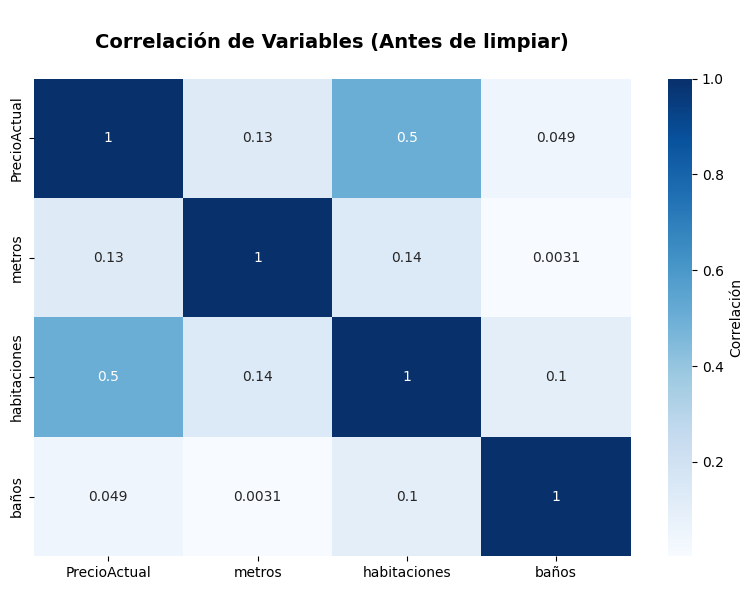

Correlación con el precio:

PrecioActual    1.000000
habitaciones    0.504158
metros          0.130661
baños           0.048852
Name: PrecioActual, dtype: float64


In [45]:
plt.figure(figsize=(8, 6))
sns.heatmap(df_para_heatmap.corr(), annot=True, cmap='Blues', cbar_kws={'label': 'Correlación'})
plt.title('\nCorrelación de Variables (Antes de limpiar)\n', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Correlación con el precio:\n')
print(df_para_heatmap.corr()['PrecioActual'].sort_values(ascending=False))

# Estudio de pisos anomalos 

Text(0.5, 1.0, 'Metros vs Precio Actual')

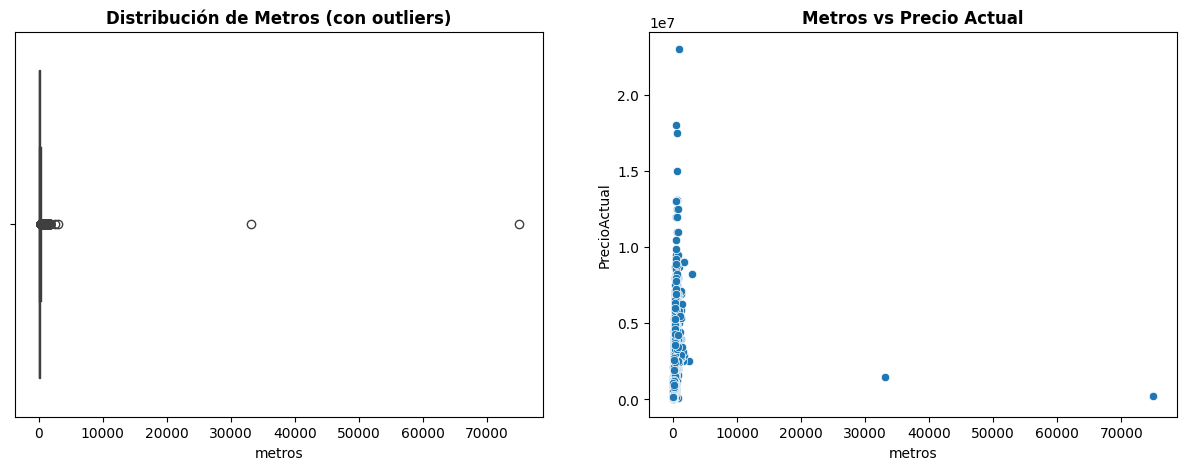

In [49]:
#Una figura con dos graficos dentro 
fig, axes = plt.subplots(1,2, figsize=(15,5))

#Crar graf blox | x=m2 | en el grafico izquierda
sns.boxplot(x=df['metros'], ax=axes[0])
axes[0].set_title('Distribución de Metros (con outliers)', fontweight='bold')

#Grafico derecha
sns.scatterplot(data=df, x='metros', y='PrecioActual', ax=axes[1], alpha=1.0)
axes[1].set_title('Metros vs Precio Actual', fontweight='bold')



In [74]:
filtro_metros = df.query('metros > 30000')

print(f"Número de registros com metros > 30000: {len(filtro_metros)}")

display(filtro_metros)

Número de registros com metros > 30000: 2


,provincia,zona,titulo,PrecioActual,PrecioAnterior,metros,habitaciones,ascensor,localizacion,planta,baños,tags,descripcion,Enlace
6979,madrid,ciudad-lineal,"Piso en calle de Emilio Ferrari, s/n, Pueblo N...",192000,0,75000,3.0,N,EXTERIOR,1ª,0,"VIVIENDA,INMOBILIARIA",VIVIENDA OCUPADASe admiten ofertas***SIN COMIS...,https://www.idealista.com/inmueble/107196960/
7997,madrid,hortaleza,"Chalet adosado en Palomas, Madrid",1495000,0,33175,7.0,NaN,NaN,NaN,0,"AMPLIO,EXCLUSIVA,OPORTUNIDAD,CHALET,REFORMAR,M...",Este fantástico pareado se encuentra en Piover...,https://www.idealista.com/inmueble/106105382/


In [75]:
print(f"Número de registros com PrecioActual > 20000000: ")
df.query('PrecioActual>20000000')


Número de registros com PrecioActual > 20000000: 


,provincia,zona,titulo,PrecioActual,PrecioAnterior,metros,habitaciones,ascensor,localizacion,planta,baños,tags,descripcion,Enlace
6489,madrid,chamartin,Casa o chalet independiente en calle de Castel...,23000000,0,1000,7.0,NaN,NaN,NaN,0,CASA,Lucía Suárez-Zuloaga de GV | EL VISO comercial...,https://www.idealista.com/inmueble/107095805/


<Axes: title={'center': 'Distribución de precios antes de remover outliers'}, xlabel='PrecioActual', ylabel='Count'>

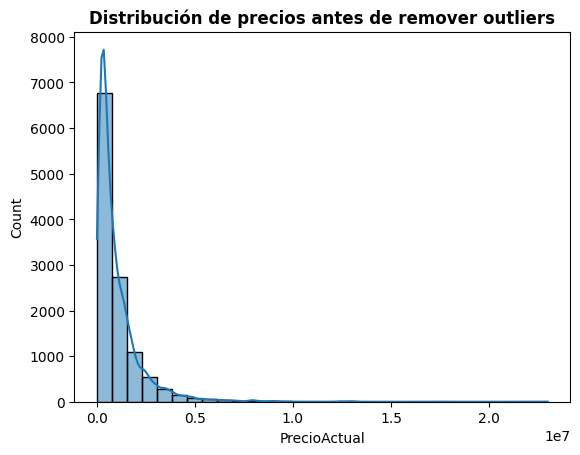

In [48]:
plt.title('Distribución de precios antes de remover outliers', fontweight='bold'); 
sns.histplot(df['PrecioActual'], bins=30, kde=True)

Escribir resumen de los estudios anomalos 

## Limpieza de datos

In [77]:
#copia
df_clean = df.copy()

In [78]:
# Rellenar nulos de las columnas que vamos a usar
# Usamos la mediana para que las casas de lujo no nos arruinen el promedio
df_clean['metros'] = df_clean['metros'].fillna(df_clean['metros'].median())
df_clean['habitaciones'] = df_clean['habitaciones'].fillna(df_clean['habitaciones'].median())
df_clean['baños'] = df_clean['baños'].fillna(df_clean['baños'].median())

In [79]:
df_clean['zona'] = df_clean['zona'].fillna(df_clean['zona'].mode()[0])

In [80]:
# Para el texto, ponemos lo que más se repite (la moda)
df_clean['zona'] = df_clean['zona'].fillna(df_clean['zona'].mode()[0])
df_clean['localizacion'] = df_clean['localizacion'].fillna(df_clean['localizacion'].mode()[0])
df_clean['ascensor'] = df_clean['ascensor'].fillna(df_clean['ascensor'].mode()[0])


In [81]:
#El precio es la variable que queremos predecir, así que si falta, esa fila no sirve para entrenar.
df_clean = df_clean.dropna(subset=['PrecioActual'])

In [82]:
# Borramos las que no tienen precio porque no nos sirven para el modelo
df_clean.dropna(subset=['PrecioActual'], inplace=True)

In [83]:
# Borramos duplicados
df_clean = df_clean.drop_duplicates()

### Realizar **IQR** para ver cuanto ocupa el 50% central de los datos
    
      

In [87]:
Q1=df['metros'].quantile(0.25) # El 25% de tus pisos miden 68 m² o menos (Q1 = 68).
Q3=df['metros'].quantile(0.75) # El 75% de tus pisos miden 160 m² o menos (Q3 = 160).

IQR=Q3-Q1 # La diferencia entre ambos es donde se concentra la gran mayoría del dataset

limite_inferior = 15

#Cojamos el Q3 y le sumemos 3 veces el IQR
limite_superior =  Q3 + 3.0 * IQR # = equivale  a 436m


#Filtrar
df_limpio = df[(df['metros'] >= limite_inferior) & (df['metros'] <= limite_superior)].copy()



In [91]:
df_model = df_clean.copy()

# Filtramos los metros y precios para quedarnos con casos razonables
df_model = df_model[(df_model['metros'] > 20) & (df_model['metros'] < 300)]

df_model = df_model[df_model['PrecioActual'] < 1000000]

print(f"Tenemos {len(df_model)} filas listas para el modelo.")

Tenemos 7870 filas listas para el modelo.


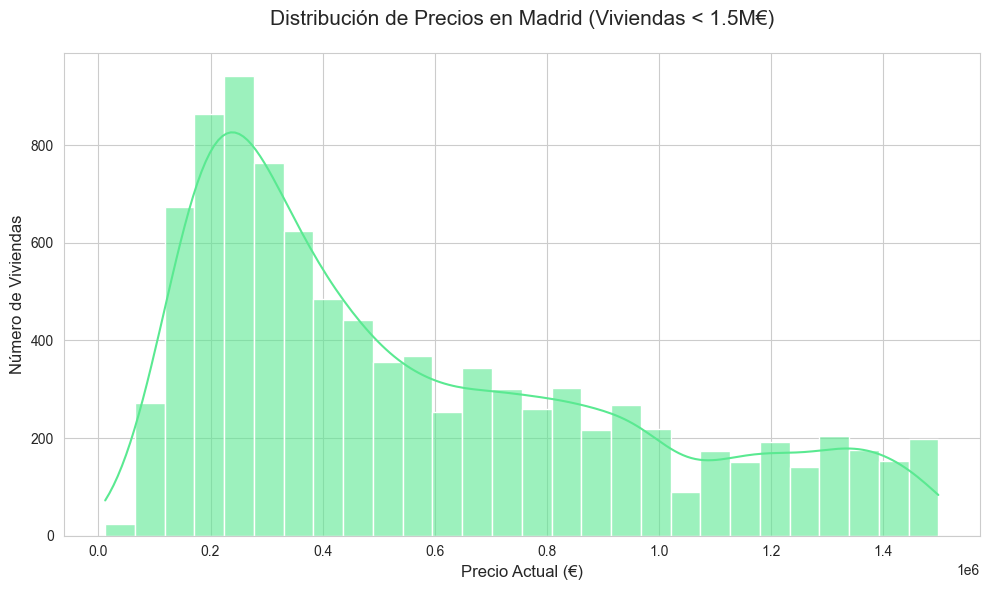

In [90]:
df_grafico = df_clean[df_clean['PrecioActual'] < 1500000]

# Configuramos el estilo
sns.set_style("whitegrid") 
plt.figure(figsize=(10, 6))

#Creación del histograma
sns.histplot(
    df_grafico['PrecioActual'], 
    kde=True, 
    color="#5ae991", 
    alpha=0.6,       
    edgecolor='white'
)

plt.title('Distribución de Precios en Madrid (Viviendas < 1.5M€)', fontsize=15, pad=20)
plt.xlabel('Precio Actual (€)', fontsize=12)
plt.ylabel('Número de Viviendas', fontsize=12)

plt.tight_layout()
plt.show()

In [88]:
print('Dataset después de limpiar:', df_clean.shape)
print('Valores faltantes totales:', int(df_clean.isna().sum().sum()))
print("Filas eliminadas:", df.shape[0] - df_limpio.shape[0])

Dataset después de limpiar: (11826, 14)
Valores faltantes totales: 1452
Filas eliminadas: 475


### Grafico después de la limpieza


Text(0.5, 1.0, 'Metros vs Precio Actual (Post Limpieza)')

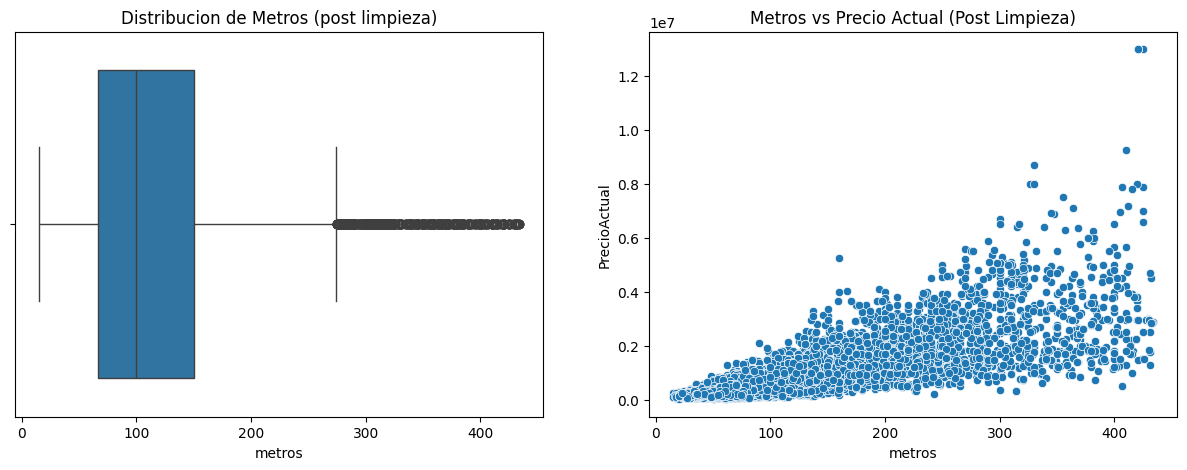

In [89]:
fix, axes = plt.subplots(1,2, figsize=(15, 5))

sns.boxplot(x=df_limpio['metros'], ax=axes[0])
axes[0].set_title('Distribucion de Metros (post limpieza)')

sns.scatterplot(data=df_limpio, x='metros', y='PrecioActual', ax=axes[1], alpha=1.0)
axes[1].set_title('Metros vs Precio Actual (Post Limpieza)')

In [19]:
# no se si dejar estos pisos
#podria = dejarlos, eliminarlos, hacer una "transformacion algoritmica" para que se enconga la diferencia, o segmentarlo(en superLujo=1)

df_limpio.query('PrecioActual > 12000000').sort_values(by='PrecioActual', ascending=False)

,provincia,zona,titulo,PrecioActual,PrecioAnterior,metros,habitaciones,ascensor,localizacion,planta,baños,tags,descripcion,Enlace
6191,madrid,barrio-de-salamanca,"Piso en calle de Velázquez, Recoletos, Madrid",13000000,0,421,5.0,S,EXTERIOR,3ª,0,"VIVIENDA,PISO,REFORMADO,LUJO,ELECTRODOMÉSTICOS...",Olivares Consultores vende esta vivienda de lu...,https://www.idealista.com/inmueble/106652699/
6546,madrid,barrio-de-salamanca,"Piso en calle Velázquez, Recoletos, Madrid",13000000,0,425,5.0,S,EXTERIOR,3ª,0,"VIVIENDA,INMOBILIARIA","Álvora Capital Properties, consultora inmobili...",https://www.idealista.com/inmueble/107166409/
7522,madrid,barrio-de-salamanca,"Piso en calle Velázquez, Recoletos, Madrid",13000000,0,421,5.0,S,EXTERIOR,3ª,0,"VIVIENDA,PISO,LUJO,ESPECTACULAR,EXCLUSIVO,INMO...",REA Inmobiliaria presenta este exclusivo piso ...,https://www.idealista.com/inmueble/107212046/
7614,madrid,barrio-de-salamanca,"Piso en Recoletos, Madrid",13000000,0,421,5.0,S,EXTERIOR,3ª,0,"VIVIENDA,PISO,EXCLUSIVA,LUJO,ESPECTACULAR,FINC...",Presentamos esta espectacular y exclusiva vivi...,https://www.idealista.com/inmueble/107165396/
9675,madrid,barrio-de-salamanca,"Piso en Recoletos, Madrid",13000000,0,421,5.0,S,EXTERIOR,3ª,0,"VIVIENDA,PISO,REFORMADO,EXCLUSIVA,LUJO,ESPECTA...",Olisson Club pone a su disposición esta espect...,https://www.idealista.com/inmueble/106771279/


In [20]:
#viendo el codigo de arriba me doy cuenta de que duplicados, decidor eliminarlos 
df_limpio = df_limpio.drop_duplicates(subset=['titulo', 'PrecioActual', 'metros'])

In [21]:
df.shape

(11826, 14)

3. Sacar la correlacin para ver como cambio en relacion a la anterior que estaba con outiers 

In [22]:
df_limpio.select_dtypes(include='number').corr()['PrecioActual'].drop('PrecioActual').sort_values(ascending=False)

metros            0.784782
habitaciones      0.423971
PrecioAnterior    0.130072
baños             0.069455
Name: PrecioActual, dtype: float64

**2. VER HABITACIONES**

Cuando se hizo el *describe*, habia  361 valores nulos (NaN) y un valor máximo de 20 habitaciones que suena a otro error (o es un hotel) 


Text(0.5, 1.0, 'Relación entre habitaciones y precio')

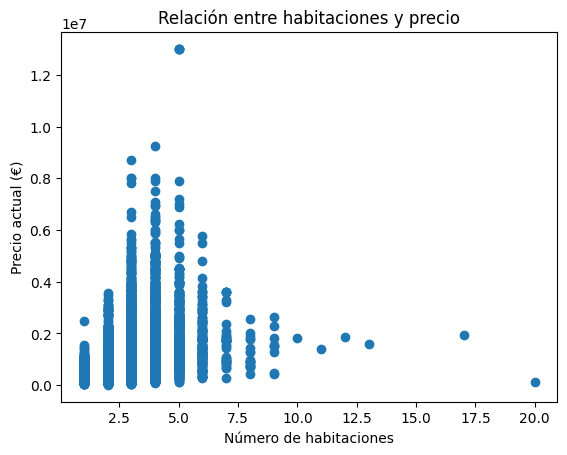

In [23]:
plt.scatter(x='habitaciones', y='PrecioActual', alpha=1.0, data=df_limpio) 

plt.xlabel('Número de habitaciones')   # eje X
plt.ylabel('Precio actual (€)')        # eje Y
plt.title('Relación entre habitaciones y precio')

In [24]:
#AL HACER UN df_limpio.query() me di cuenta de que  HABIA PISOS IGUALES 

# 1. Definimos las columnas que "delatan" al mismo piso
columnas_clave = ['PrecioActual', 'zona', 'planta', 'habitaciones']

# 2. Eliminamos los duplicados basándonos en esas claves
# 'keep=first' significa que nos quedamos con el primer anuncio que encuentre
df_limpio = df_limpio.drop_duplicates(subset=columnas_clave, keep='first').copy()


1. HACEMOS UNA LIMPIEZA DE OUTLINERS

    Nos quedamos solo con viviendas de entre 1 y 10 habitaciones
    (Eliminamos el error de 20 y posibles locales de 0)

    Rellenamos los huecos vacíos (NaN) con la median

In [25]:

df_limpio.query('habitaciones >= 10')

df_limpio = df_limpio[df_limpio['habitaciones'] < 10].copy()

In [26]:
df_limpio.drop(index=6191, inplace=True)

Text(0.5, 1.0, 'Relación entre habitaciones y precio PostLimpieza')

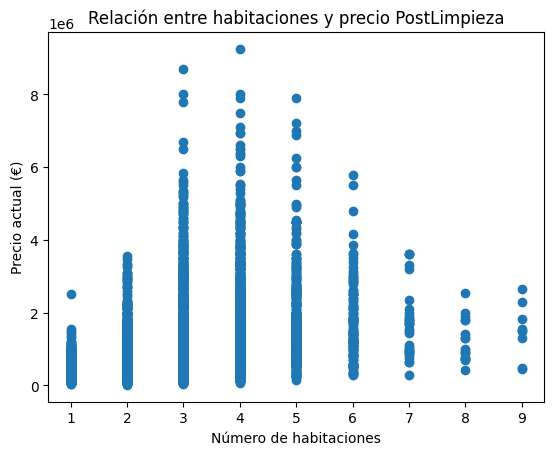

In [27]:
plt.scatter(x='habitaciones', y='PrecioActual', alpha=1.0, data=df_limpio) 

plt.xlabel('Número de habitaciones')   # eje X
plt.ylabel('Precio actual (€)')        # eje Y
plt.title('Relación entre habitaciones y precio PostLimpieza')


In [28]:

df_limpio['habitaciones'] = df['habitaciones'].fillna(df['habitaciones'].median())

In [29]:
df_limpio.select_dtypes(include='number').corr()['PrecioActual'].drop('PrecioActual').sort_values(ascending=False)

metros            0.794192
habitaciones      0.427032
PrecioAnterior    0.142687
baños             0.072204
Name: PrecioActual, dtype: float64

In [30]:
 df_limpio.shape

(8511, 14)

# no se si tendre que arreglar habitaciones tiene una CORRELACION 0.4

2. **BAÑOS**
   
* Esta variable genera dudas, ya que el análisis con describe() indica que casi todo el dataset tiene valor 0, lo cual resulta poco realista.
* Teniendo en cuenta esto, no estaba claro si eliminar la columna (drop) o intentar corregirla de alguna forma.

Text(0, 0.5, 'Precio (millones)')

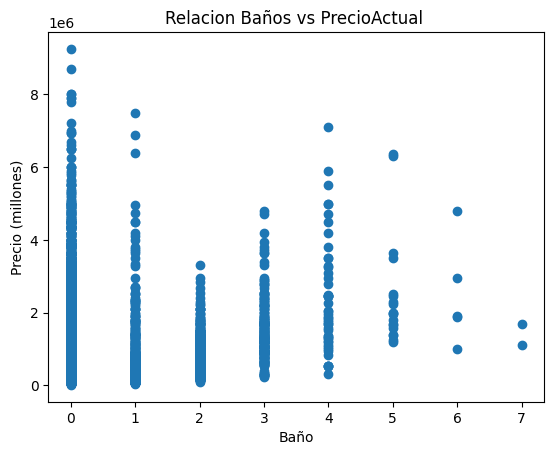

In [31]:
plt.scatter(data=df_limpio, x='baños', y='PrecioActual')
plt.title('Relacion Baños vs PrecioActual ')
plt.xlabel('Baño')
plt.ylabel('Precio (millones)')

**2.1.Intento de Arreglo**

In [32]:
# 1. Todo lo que sea 0 baños, pasa a ser 1 (mínimo habitable)
df_limpio.loc[df_limpio['baños'] == 0, 'baños'] = 1

# 2. Si el piso es grande (>110 m2) y tiene 1 baño, le ponemos 2
df_limpio.loc[(df_limpio['baños'] == 1) & (df_limpio['metros'] > 110), 'baños'] = 2

# 3. Si el piso es muy grande (>200 m2) y tiene 1 o 2, le ponemos 3
df_limpio.loc[(df_limpio['baños'] < 3) & (df_limpio['metros'] > 200), 'baños'] = 3

# 4. Calculamos la nueva correlación
print("Nueva tabla de correlaciones:")
df_limpio.select_dtypes(include='number').corr()['PrecioActual'].drop('PrecioActual').sort_values(ascending=False)

Nueva tabla de correlaciones:


metros            0.794192
baños             0.696328
habitaciones      0.427032
PrecioAnterior    0.142687
Name: PrecioActual, dtype: float64

Text(0, 0.5, 'Precio (millones)')

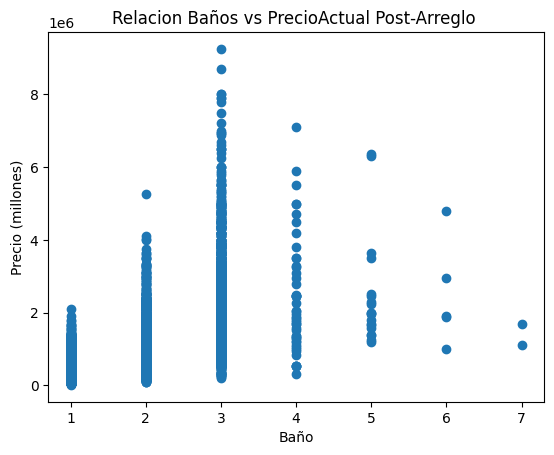

In [33]:
plt.scatter(data=df_limpio, x='baños', y='PrecioActual')
plt.title('Relacion Baños vs PrecioActual Post-Arreglo ')
plt.xlabel('Baño')
plt.ylabel('Precio (millones)')

In [34]:
df_limpio.shape

(8511, 14)

3. **PrecioAnterior**

In [35]:
# Creamos una columna: 1 si tiene precio anterior (hubo rebaja), 0 si no.
df_limpio['tiene_rebaja'] = (df_limpio['PrecioAnterior'] > 0).astype(int)

# Miramos si "tener rebaja" ayuda a predecir el precio actual
print("Correlación de 'tiene_rebaja':")
print(df_limpio['tiene_rebaja'].corr(df_limpio['PrecioActual']))

Correlación de 'tiene_rebaja':
-0.06221717993724008


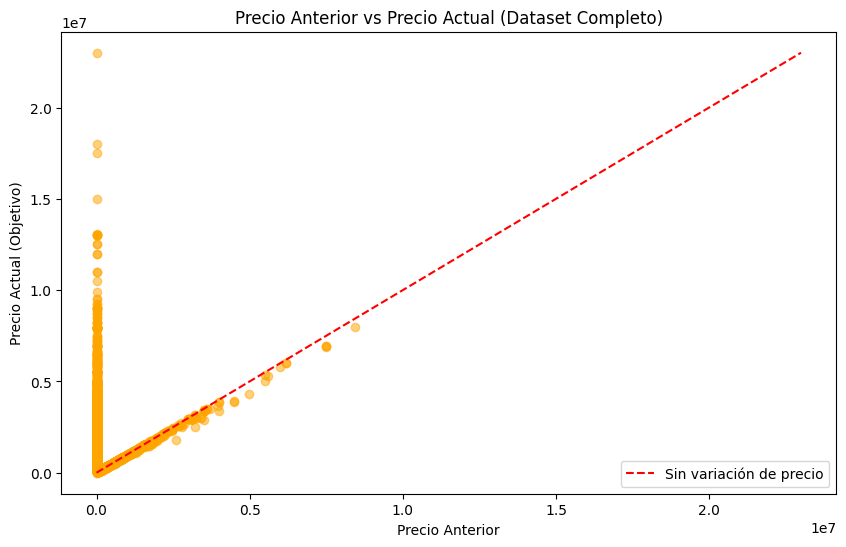

In [36]:
# Crear la figura con un buen tamaño
plt.figure(figsize=(10, 6))

# Dibujar todos los datos sin filtrar (alpha=0.5 añade transparencia)
plt.scatter(x=df['PrecioAnterior'], y=df['PrecioActual'], alpha=0.5, color='orange')

# Trazar una línea roja diagonal de referencia (PrecioAnterior == PrecioActual)
max_val = max(df['PrecioAnterior'].max(), df['PrecioActual'].max())
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', label='Sin variación de precio')

# Títulos y etiquetas
plt.xlabel('Precio Anterior')
plt.ylabel('Precio Actual (Objetivo)')
plt.title('Precio Anterior vs Precio Actual (Dataset Completo)')
plt.legend()

# Mostrar la gráfica
plt.show()

el 95% de los pisos, el PrecioAnterior es exactamente igual al PrecioActual (porque nunca han bajado de precio). i metes PrecioAnterior como una variable más (X) para que tu modelo adivine el PrecioActual (Y), el modelo se volverá "vago". Se dará cuenta de que la forma más fácil de acertar es simplemente copiar el valor de PrecioAnterior

**3.eliminar pisos con precio 0 o null o nan y volver a ver la correlacion**

In [37]:
#print(f"Filas antes de limpiar: {len(df)}")

# Nos aseguramos de que ambas columnas sean tratadas como números.
# Si hay algún texto raro o vacío, se convertirá en NaN automáticamente.
#df_limpio['PrecioActual'] = pd.to_numeric(df['PrecioActual'], errors='coerce')
#df_limpio['PrecioAnterior'] = pd.to_numeric(df['PrecioAnterior'], errors='coerce')

# Eliminamos cualquier fila que tenga un NaN en alguna de estas dos columnas
#df_limpio = df_limpio.dropna(subset=['PrecioActual', 'PrecioAnterior'])

# Nos quedamos estrictamente con los pisos que cuesten más de 0€
# (esto elimina los 0 y también posibles precios negativos si hubiera errores)
#df_limpio = df_limpio[(df_limpio['PrecioActual'] > 0) & (df_limpio['PrecioAnterior'] > 0)]

#print(f"Filas después de limpiar: {len(df_limpio)}")
#print("-" * 50)

In [38]:
# 1. Creamos la columna de descuento porcentual
# Si no hay PrecioAnterior, el descuento es 0
df_limpio['pct_descuento'] = (df_limpio['PrecioAnterior'] - df_limpio['PrecioActual']) / df_limpio['PrecioAnterior']

# 2. Los que no tenían precio anterior (NaN o Infinito por dividir por 0) los ponemos a 0
df_limpio['pct_descuento'] = df_limpio['pct_descuento'].fillna(0)
# En caso de que PrecioAnterior fuera 0, la división da inf, corregimos:
import numpy as np
df_limpio['pct_descuento'] = df_limpio['pct_descuento'].replace([np.inf, -np.inf], 0)

# 3. Limpiamos posibles errores (descuentos negativos o > 100%)
df_limpio.loc[df_limpio['pct_descuento'] < 0, 'pct_descuento'] = 0

In [39]:
df_limpio.select_dtypes(include='number').corr()['PrecioActual'].drop('PrecioActual').sort_values(ascending=False)

metros            0.794192
baños             0.696328
habitaciones      0.427032
PrecioAnterior    0.142687
pct_descuento    -0.045294
tiene_rebaja     -0.062217
Name: PrecioActual, dtype: float64

In [40]:
df_limpio.shape

(8511, 16)

# *PERDIDA DE 8MIL FILAS EN LA VARIBLE PRECIOANTERIOR***

intente hacer lo de crear descuento, y rebaja, pero la correlacion sigue siendo muy baja. Lo mejor creo que va a ser no usar la columnaPrecioAnterior

# BUSCAR CORRELACION ENTRE VARIABLE **ZONA** CON VARIABLE OBJETIVO (PrecioActual) --> FUMATIDA DE SERGIO


Al ser una varible 